In [1]:
# ============================================================
# STUDENT QUERY CLASSIFICATION PROJECT
# Dataset: Student Queries Data.xlsx
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================

import sys
import subprocess
import os
import re
import warnings

warnings.filterwarnings("ignore")

required_packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "nltk",
    "wordcloud",
    "joblib",
    "openpyxl",
    "flask"
]

for package in required_packages:
    try:
        __import__(package.replace("-", "_"))
    except ImportError:
        print("Installing:", package)
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package]
        )

# XGBoost is optional because installation can vary by computer.
# The notebook will continue normally if it cannot be imported.
try:
    import xgboost
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

print("Package setup complete.")


Installing: scikit-learn
Package setup complete.


In [2]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import joblib


In [3]:
# ============================================================
# 3. DOWNLOAD NLTK RESOURCES
# ============================================================

print("\nPreparing NLTK resources...")

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))

# Keep important question words.
# Removing these can sometimes hurt classification.
words_to_keep = {
    "how",
    "what",
    "why",
    "when",
    "where",
    "which",
    "can",
    "could",
    "should",
    "would",
    "is",
    "are",
    "do",
    "does"
}

stop_words = stop_words - words_to_keep

lemmatizer = WordNetLemmatizer()

print("NLTK setup complete.")



Preparing NLTK resources...
NLTK setup complete.


In [4]:
# ============================================================
# 4. PROJECT SETTINGS
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
#
# False = 3-class classification:
#         Academic
#         Course Query
#         Technical
#
# True = binary classification:
#        Academic
#        Technical
#
# In binary mode, Course Query is grouped into Academic.
# ------------------------------------------------------------

BINARY_MODE = False

RANDOM_STATE = 42
TEST_SIZE = 0.20

MAX_FEATURES = 500

OUTPUT_FOLDER = "student_query_project_output"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("\nProject settings:")
print("BINARY_MODE =", BINARY_MODE)
print("TEST_SIZE =", TEST_SIZE)
print("MAX_FEATURES =", MAX_FEATURES)


Project settings:
BINARY_MODE = False
TEST_SIZE = 0.2
MAX_FEATURES = 500


In [5]:

# ============================================================
# 5. FIND THE EXCEL FILE
# ============================================================

print("\nSearching for the dataset...")

possible_files = [
    "Student Queries Data.xlsx",
    "/mnt/data/Student Queries Data.xlsx"
]

file_path = None

for path in possible_files:
    if os.path.exists(path):
        file_path = path
        break

# If not found, search current folder
if file_path is None:
    excel_files = [
        f for f in os.listdir(".")
        if f.lower().endswith((".xlsx", ".xls"))
    ]

    preferred = [
        f for f in excel_files
        if "student" in f.lower() or "quer" in f.lower()
    ]

    if len(preferred) > 0:
        file_path = preferred[0]
    elif len(excel_files) > 0:
        file_path = excel_files[0]

if file_path is None:
    raise FileNotFoundError(
        "Could not find the Excel file. "
        "Make sure 'Student Queries Data.xlsx' is uploaded "
        "to the same folder as this notebook."
    )

print("Dataset found:", file_path)


Searching for the dataset...
Dataset found: Student Queries Data.xlsx


In [6]:
# ============================================================
# 6. LOAD DATASET
# ============================================================

df = pd.read_excel(file_path)

print("\nDataset loaded successfully.")

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())



Dataset loaded successfully.
Shape: (22094, 3)

Columns:
['query', 'queryType', 'answer']

First 5 rows:


,query,queryType,answer
0,explain recession,Academic,<!--StartFragment-->A recession is a macroecon...
1,define types of economics names,technical,<!--StartFragment-->Microeconomics is&nbsp;the...
2,wish you a happy new year mam,Academic,Happy New Year to you too&nbsp;
3,Sir your lectures are really helpful can u ple...,Course Query,"<!--StartFragment--><h4 style=""box-sizing: bor..."
4,are there any seperate marks for diagram in th...,Course Query,No separate marks allocated...nor in Exam u wi...


In [7]:
# ============================================================
# 7. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = ["query", "queryType"]

for column in required_columns:
    if column not in df.columns:
        raise ValueError(
            f"Required column '{column}' was not found.\n"
            f"Available columns: {df.columns.tolist()}"
        )

print("\nRequired columns found.")




Required columns found.


In [8]:

# ============================================================
# 8. INITIAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("INITIAL DATASET INFORMATION")
print("=" * 70)

print("\nNumber of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nOriginal queryType distribution:")
print(df["queryType"].value_counts(dropna=False))


INITIAL DATASET INFORMATION

Number of rows: 22094
Number of columns: 3

Missing values:
query          2
queryType      0
answer       354
dtype: int64

Original queryType distribution:
queryType
Course Query    11892
Academic         7415
technical        2078
Technical         709
Name: count, dtype: int64


In [9]:
# ============================================================
# 9. KEEP ONLY NECESSARY COLUMNS
# ============================================================

# We classify based on the student's query.
# The answer is NOT used as an input feature because doing so
# could create information leakage.

data = df[["query", "queryType"]].copy()

data = data.rename(
    columns={
        "query": "Query",
        "queryType": "Category"
    }
)



In [10]:


# ============================================================
# 10. REMOVE MISSING VALUES
# ============================================================

data["Query"] = data["Query"].fillna("").astype(str)
data["Category"] = data["Category"].fillna("").astype(str)

data["Query"] = data["Query"].str.strip()
data["Category"] = data["Category"].str.strip()

data = data[
    (data["Query"] != "") &
    (data["Category"] != "")
].copy()

print("\nRows after removing missing query/category values:", len(data))


Rows after removing missing query/category values: 22091


In [11]:
# ============================================================
# 11. STANDARDIZE CATEGORY LABELS
# ============================================================

# Convert technical / Technical into one class.

def standardize_category(label):
    label_clean = str(label).strip().lower()

    if label_clean == "technical":
        return "Technical"

    if label_clean == "academic":
        return "Academic"

    if label_clean == "course query":
        return "Course Query"

    return str(label).strip()


data["Category"] = data["Category"].apply(standardize_category)


In [12]:
# ============================================================
# 12. OPTIONAL BINARY CLASSIFICATION
# ============================================================

if BINARY_MODE:

    print("\nBinary classification selected.")

    # Course Query is grouped into Academic.
    data["Category"] = data["Category"].replace(
        {
            "Course Query": "Academic"
        }
    )

else:

    print("\nThree-class classification selected.")



Three-class classification selected.


In [13]:
# ============================================================
# 13. REMOVE DUPLICATE QUERIES
# ============================================================

before_duplicates = len(data)

data = data.drop_duplicates(
    subset=["Query", "Category"]
).reset_index(drop=True)

duplicates_removed = before_duplicates - len(data)

print("Duplicate rows removed:", duplicates_removed)
print("Rows remaining:", len(data))

Duplicate rows removed: 564
Rows remaining: 21527


In [14]:
# ============================================================
# 14. TEXT CLEANING FUNCTION
# ============================================================

def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove HTML entities
    text = re.sub(r"&[a-zA-Z0-9#]+;", " ", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove email addresses
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " ",
        text
    )

    # Keep letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize safely without requiring punkt
    tokens = re.findall(r"[a-zA-Z]+", text)

    cleaned_tokens = []

    for token in tokens:

        if token in stop_words:
            continue

        if len(token) <= 1:
            continue

        try:
            token = lemmatizer.lemmatize(token)
        except Exception:
            pass

        cleaned_tokens.append(token)

    return " ".join(cleaned_tokens)


print("\nCleaning text...")



Cleaning text...


In [15]:
# ============================================================
# 15. CREATE CLEAN QUERY COLUMN
# ============================================================

data["Clean_Query"] = data["Query"].apply(clean_text)

# Remove rows that became empty after cleaning
data = data[data["Clean_Query"].str.strip() != ""].reset_index(drop=True)

print("Text cleaning complete.")

print("\nExample before/after cleaning:")

display(
    data[["Query", "Clean_Query", "Category"]].head(10)
)



Text cleaning complete.

Example before/after cleaning:


,Query,Clean_Query,Category
0,explain recession,explain recession,Academic
1,define types of economics names,define type economics name,Technical
2,wish you a happy new year mam,wish happy new year mam,Academic
3,Sir your lectures are really helpful can u ple...,sir lecture are really helpful can please answ...,Course Query
4,are there any seperate marks for diagram in th...,are seperate mark diagram exam,Course Query
5,Is Fiancial Statement prepare for Business pur...,is fiancial statement prepare business purpose...,Academic
6,"Sir, please refer Session 3- Slide No. 32 ,33...",sir please refer session slide recognition int...,Technical
7,Good Evening sir. I did not understand what BA...,good evening sir understand what barnacle mean...,Academic
8,"Sir, Please tell us whether we have to memoriz...",sir please tell u whether memorize entire chap...,Course Query
9,"Sir, Please guide us how to prepare for the ex...",sir please guide u how prepare examination,Course Query


In [16]:
# ============================================================
# 16. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET")
print("=" * 70)

print("Rows:", len(data))
print("Columns:", len(data.columns))

print("\nClass distribution:")
print(data["Category"].value_counts())

print("\nClass percentages:")
print(
    (data["Category"].value_counts(normalize=True) * 100)
    .round(2)
)


FINAL DATASET
Rows: 21519
Columns: 3

Class distribution:
Category
Course Query    11449
Academic         7349
Technical        2721
Name: count, dtype: int64

Class percentages:
Category
Course Query    53.20
Academic        34.15
Technical       12.64
Name: proportion, dtype: float64


In [17]:
# ============================================================
# 17. SAVE CLEANED DATASET
# ============================================================

cleaned_file = os.path.join(
    OUTPUT_FOLDER,
    "clean_student_queries.xlsx"
)

data.to_excel(
    cleaned_file,
    index=False
)

print("\nCleaned dataset saved to:")
print(cleaned_file)



Cleaned dataset saved to:
student_query_project_output/clean_student_queries.xlsx


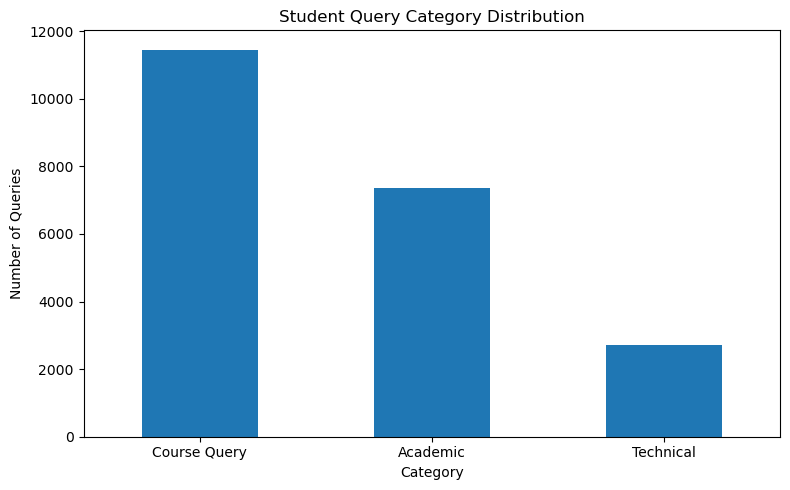

In [18]:
# ============================================================
# 18. EDA - CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

data["Category"].value_counts().plot(
    kind="bar"
)

plt.title("Student Query Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Queries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



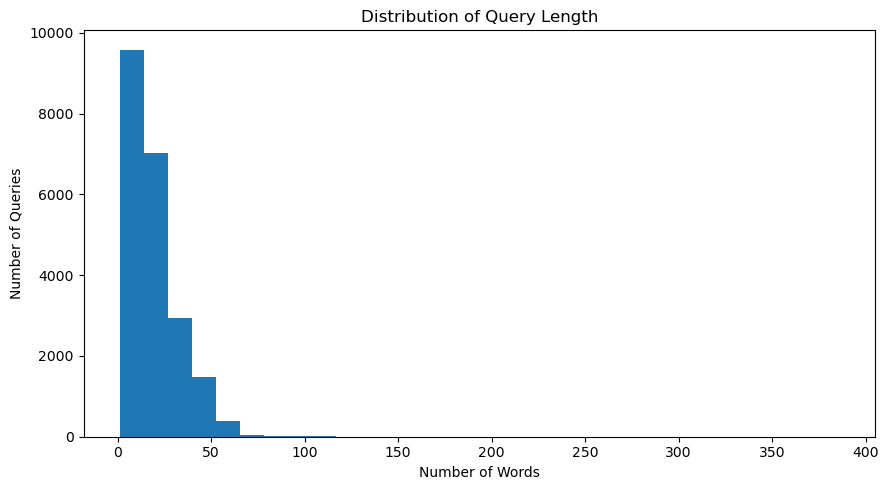


Query length statistics:
count    21519.000000
mean        18.933408
std         13.548887
min          1.000000
25%          9.000000
50%         15.000000
75%         25.000000
max        386.000000
Name: Query_Length, dtype: float64


In [19]:
# ============================================================
# 19. EDA - QUERY LENGTH
# ============================================================

data["Query_Length"] = data["Clean_Query"].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(9, 5))

plt.hist(
    data["Query_Length"],
    bins=30
)

plt.title("Distribution of Query Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Queries")
plt.tight_layout()
plt.show()

print("\nQuery length statistics:")
print(data["Query_Length"].describe())

In [20]:
# ============================================================
# 20. TOP WORDS
# ============================================================

all_words = []

for text in data["Clean_Query"]:
    all_words.extend(text.split())

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

print("\nTop 20 words:")
display(top_words_df)


Top 20 words:


,Word,Frequency
0,is,15819
1,can,7341
2,question,7158
3,sir,6593
4,please,5937
5,what,5118
6,are,5038
7,assignment,4664
8,how,3755
9,mam,3675


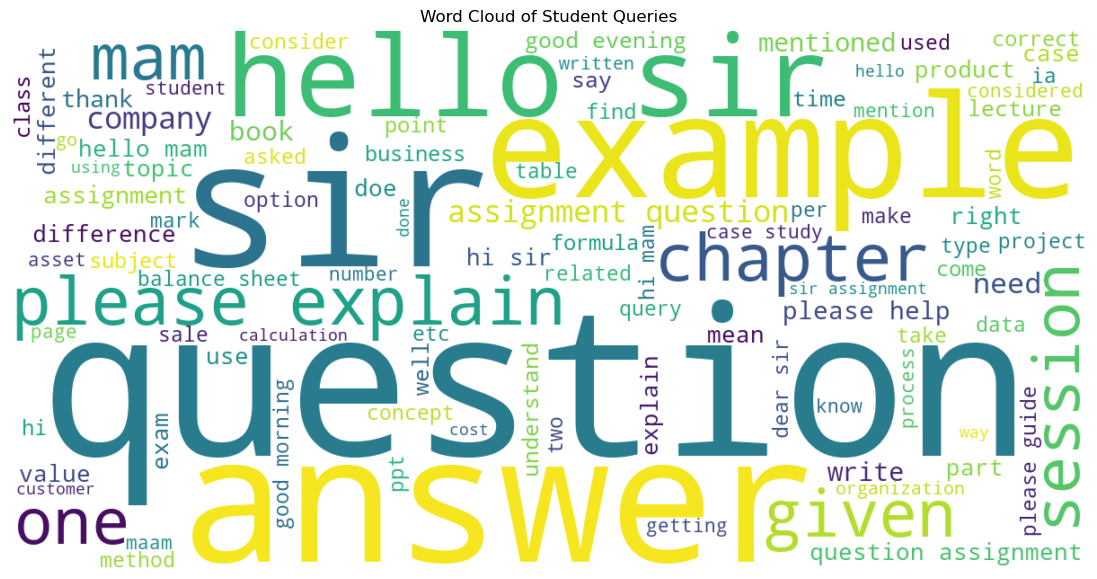

In [21]:
# ============================================================
# 21. WORD CLOUD
# ============================================================

all_text = " ".join(data["Clean_Query"].tolist())

if all_text.strip():

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=100
    ).generate(all_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Student Queries")
    plt.show()

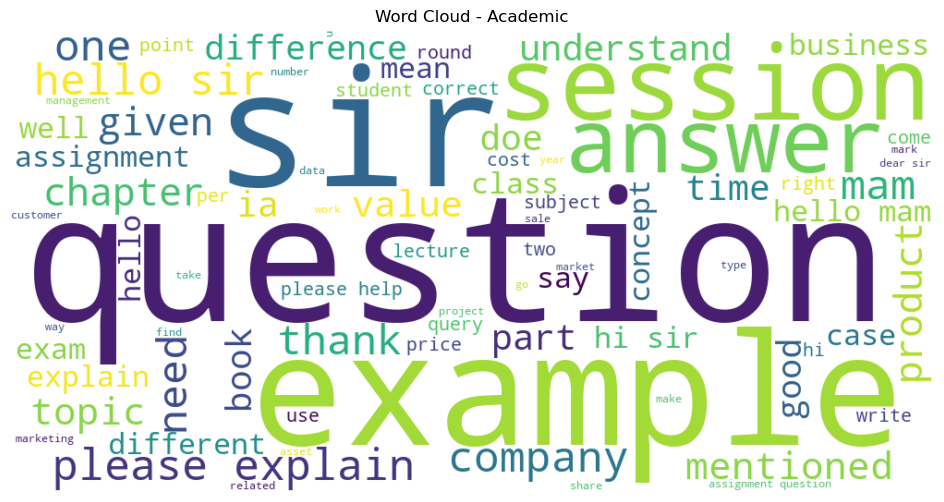

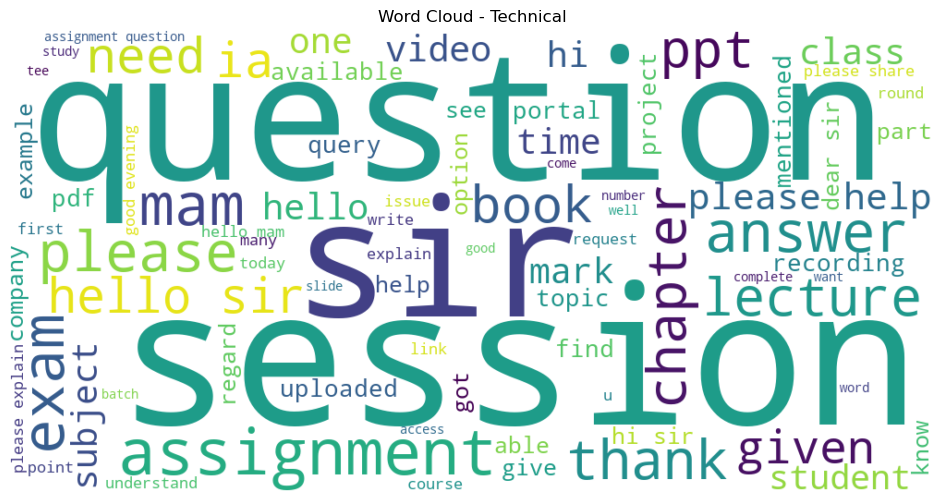

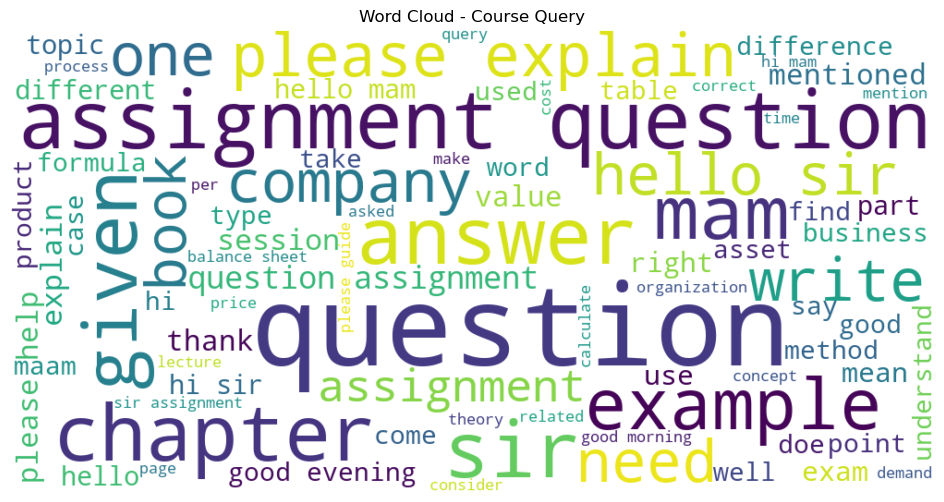

In [22]:
# ============================================================
# 22. WORD CLOUD BY CATEGORY
# ============================================================

categories = data["Category"].unique()

for category in categories:

    category_text = " ".join(
        data.loc[
            data["Category"] == category,
            "Clean_Query"
        ].tolist()
    )

    if category_text.strip():

        wc = WordCloud(
            width=1000,
            height=500,
            background_color="white",
            max_words=80
        ).generate(category_text)

        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Word Cloud - {category}")
        plt.show()


In [23]:
# ============================================================
# 23. PREPARE X AND Y
# ============================================================

X_text = data["Clean_Query"]
y_text = data["Category"]


In [24]:
# ============================================================
# 24. ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y_text)

print("\nEncoded classes:")

for number, label in enumerate(label_encoder.classes_):
    print(number, "=", label)



Encoded classes:
0 = Academic
1 = Course Query
2 = Technical


In [25]:
# ============================================================
# 25. TRAIN / TEST SPLIT
# ============================================================

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTraining samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))




Training samples: 17215
Testing samples: 4304


In [26]:
# ============================================================
# 26. BAG OF WORDS
# ============================================================

print("\nCreating Bag-of-Words features...")

bow_vectorizer = CountVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2)
)

X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)

print("BoW training shape:", X_train_bow.shape)
print("BoW testing shape:", X_test_bow.shape)



Creating Bag-of-Words features...
BoW training shape: (17215, 500)
BoW testing shape: (4304, 500)


In [27]:
# ============================================================
# 27. TF-IDF
# ============================================================

print("\nCreating TF-IDF features...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# IMPORTANT:
# Fit only on training data.
# This prevents test-data leakage.

X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train_text
)

X_test_tfidf = tfidf_vectorizer.transform(
    X_test_text
)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)



Creating TF-IDF features...
TF-IDF training shape: (17215, 500)
TF-IDF testing shape: (4304, 500)


In [28]:
# ============================================================
# 28. FEATURE INFORMATION
# ============================================================

feature_names = tfidf_vectorizer.get_feature_names_out()

print("\nNumber of TF-IDF features:", len(feature_names))

print("\nFirst 30 TF-IDF features:")
print(feature_names[:30])




Number of TF-IDF features: 500

First 30 TF-IDF features:
['able' 'able understand' 'access' 'according' 'account' 'accounting'
 'activity' 'actually' 'add' 'advance' 'advise' 'afternoon' 'already'
 'also' 'amount' 'analysis' 'another' 'answer' 'answer is'
 'answer question' 'approach' 'are' 'ask' 'asked' 'asking' 'assessment'
 'asset' 'assignment' 'assignment is' 'assignment question']


In [29]:
# ============================================================
# 29. BASELINE LOGISTIC REGRESSION
# ============================================================

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION")
print("=" * 70)

logistic_model = LogisticRegression(
    max_iter=3000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_tfidf
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))



LOGISTIC REGRESSION
Accuracy : 0.5546
Precision: 0.5906
Recall   : 0.5546
F1 Score : 0.5643


In [30]:
# ============================================================
# 30. LINEAR SVM
# ============================================================

print("\n" + "=" * 70)
print("LINEAR SVM")
print("=" * 70)

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_predictions = svm_model.predict(
    X_test_tfidf
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1 Score :", round(svm_f1, 4))



LINEAR SVM
Accuracy : 0.5862
Precision: 0.5878
Recall   : 0.5862
F1 Score : 0.5849


In [31]:
# ============================================================
# 31. RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("RANDOM FOREST")
print("=" * 70)

# Random Forest works with dense arrays.
# 500 features is small enough for this dataset.

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

rf_model = RandomForestClassifier(
    n_estimators=250,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train_dense,
    y_train
)

rf_predictions = rf_model.predict(
    X_test_dense
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))


RANDOM FOREST
Accuracy : 0.6087
Precision: 0.593
Recall   : 0.6087
F1 Score : 0.5919


In [32]:
# ============================================================
# 32. XGBOOST
# ============================================================

xgb_model = None
xgb_predictions = None
xgb_accuracy = None
xgb_precision = None
xgb_recall = None
xgb_f1 = None

if XGBOOST_AVAILABLE:

    print("\n" + "=" * 70)
    print("XGBOOST")
    print("=" * 70)

    try:

        from xgboost import XGBClassifier

        xgb_model = XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric="mlogloss",
            n_jobs=-1
        )

        xgb_model.fit(
            X_train_dense,
            y_train
        )

        xgb_predictions = xgb_model.predict(
            X_test_dense
        )

        xgb_accuracy = accuracy_score(
            y_test,
            xgb_predictions
        )

        xgb_precision = precision_score(
            y_test,
            xgb_predictions,
            average="weighted",
            zero_division=0
        )

        xgb_recall = recall_score(
            y_test,
            xgb_predictions,
            average="weighted",
            zero_division=0
        )

        xgb_f1 = f1_score(
            y_test,
            xgb_predictions,
            average="weighted",
            zero_division=0
        )

        print("Accuracy :", round(xgb_accuracy, 4))
        print("Precision:", round(xgb_precision, 4))
        print("Recall   :", round(xgb_recall, 4))
        print("F1 Score :", round(xgb_f1, 4))

    except Exception as e:

        print("XGBoost could not be run.")
        print("The rest of the project will continue normally.")
        print("Reason:", str(e))

else:

    print("\nXGBoost is not installed.")
    print("Skipping XGBoost so the notebook can continue without errors.")



XGBoost is not installed.
Skipping XGBoost so the notebook can continue without errors.


In [33]:
# ============================================================
# 33. INITIAL MODEL COMPARISON
# ============================================================

results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1": logistic_f1
    },
    {
        "Model": "Linear SVM",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1": svm_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1
    }
]

if xgb_model is not None:

    results.append(
        {
            "Model": "XGBoost",
            "Accuracy": xgb_accuracy,
            "Precision": xgb_precision,
            "Recall": xgb_recall,
            "F1": xgb_f1
        }
    )

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("INITIAL MODEL COMPARISON")
print("=" * 70)

display(
    results_df.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}"
        }
    )
)




INITIAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.6087,0.5930,0.6087,0.5919
1,Linear SVM,0.5862,0.5878,0.5862,0.5849
2,Logistic Regression,0.5546,0.5906,0.5546,0.5643


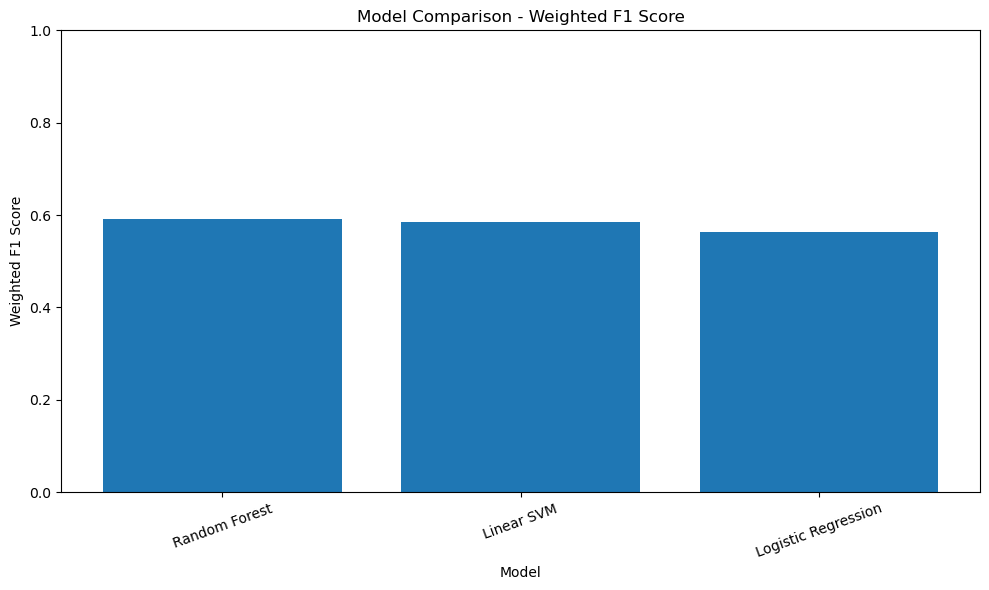

In [34]:
# ============================================================
# 34. MODEL COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["F1"]
)

plt.title("Model Comparison - Weighted F1 Score")
plt.xlabel("Model")
plt.ylabel("Weighted F1 Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [35]:
# ============================================================
# 35. HYPERPARAMETER TUNING - LOGISTIC REGRESSION
# ============================================================

print("\n" + "=" * 70)
print("TUNING LOGISTIC REGRESSION")
print("=" * 70)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

lr_grid = {
    "C": [0.1, 0.5, 1, 2, 5]
}

lr_grid_search = GridSearchCV(
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    lr_grid,
    cv=cv_strategy,
    scoring="f1_weighted",
    n_jobs=-1
)

lr_grid_search.fit(
    X_train_tfidf,
    y_train
)

tuned_lr = lr_grid_search.best_estimator_

print("Best Logistic Regression parameters:")
print(lr_grid_search.best_params_)

print(
    "Best CV F1:",
    round(lr_grid_search.best_score_, 4)
)


TUNING LOGISTIC REGRESSION
Best Logistic Regression parameters:
{'C': 0.1}
Best CV F1: 0.5655


In [36]:
# ============================================================
# 36. HYPERPARAMETER TUNING - SVM
# ============================================================

print("\n" + "=" * 70)
print("TUNING LINEAR SVM")
print("=" * 70)

svm_grid = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10]
}

svm_grid_search = GridSearchCV(
    LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    svm_grid,
    cv=cv_strategy,
    scoring="f1_weighted",
    n_jobs=-1
)

svm_grid_search.fit(
    X_train_tfidf,
    y_train
)

tuned_svm = svm_grid_search.best_estimator_

print("Best SVM parameters:")
print(svm_grid_search.best_params_)

print(
    "Best CV F1:",
    round(svm_grid_search.best_score_, 4)
)



TUNING LINEAR SVM
Best SVM parameters:
{'C': 0.01}
Best CV F1: 0.586


In [37]:
# ============================================================
# 37. TUNED MODEL EVALUATION
# ============================================================

tuned_lr_predictions = tuned_lr.predict(
    X_test_tfidf
)

tuned_svm_predictions = tuned_svm.predict(
    X_test_tfidf
)

tuned_lr_f1 = f1_score(
    y_test,
    tuned_lr_predictions,
    average="weighted",
    zero_division=0
)

tuned_svm_f1 = f1_score(
    y_test,
    tuned_svm_predictions,
    average="weighted",
    zero_division=0
)

tuned_lr_accuracy = accuracy_score(
    y_test,
    tuned_lr_predictions
)

tuned_svm_accuracy = accuracy_score(
    y_test,
    tuned_svm_predictions
)

tuned_lr_precision = precision_score(
    y_test,
    tuned_lr_predictions,
    average="weighted",
    zero_division=0
)

tuned_svm_precision = precision_score(
    y_test,
    tuned_svm_predictions,
    average="weighted",
    zero_division=0
)

tuned_lr_recall = recall_score(
    y_test,
    tuned_lr_predictions,
    average="weighted",
    zero_division=0
)

tuned_svm_recall = recall_score(
    y_test,
    tuned_svm_predictions,
    average="weighted",
    zero_division=0
)

In [38]:
# ============================================================
# 38. FINAL MODEL COMPARISON
# ============================================================

final_results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1": logistic_f1
    },
    {
        "Model": "Tuned Logistic Regression",
        "Accuracy": tuned_lr_accuracy,
        "Precision": tuned_lr_precision,
        "Recall": tuned_lr_recall,
        "F1": tuned_lr_f1
    },
    {
        "Model": "Linear SVM",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1": svm_f1
    },
    {
        "Model": "Tuned Linear SVM",
        "Accuracy": tuned_svm_accuracy,
        "Precision": tuned_svm_precision,
        "Recall": tuned_svm_recall,
        "F1": tuned_svm_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1
    }
]

if xgb_model is not None:

    final_results.append(
        {
            "Model": "XGBoost",
            "Accuracy": xgb_accuracy,
            "Precision": xgb_precision,
            "Recall": xgb_recall,
            "F1": xgb_f1
        }
    )

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    final_results_df.style.format(
        {
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}"
        }
    )
)




FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.6087,0.5930,0.6087,0.5919
1,Tuned Linear SVM,0.6013,0.5946,0.6013,0.5900
2,Linear SVM,0.5862,0.5878,0.5862,0.5849
3,Tuned Logistic Regression,0.5620,0.6001,0.5620,0.5725
4,Logistic Regression,0.5546,0.5906,0.5546,0.5643


In [39]:
# ============================================================
# 39. SELECT BEST MODEL
# ============================================================

best_model_name = final_results_df.iloc[0]["Model"]

print("\nBest model based on weighted F1:")
print(best_model_name)



Best model based on weighted F1:
Random Forest


In [40]:
# ============================================================
# 40. GET BEST MODEL OBJECT
# ============================================================

if best_model_name == "Logistic Regression":

    best_model = logistic_model
    best_predictions = logistic_predictions

elif best_model_name == "Tuned Logistic Regression":

    best_model = tuned_lr
    best_predictions = tuned_lr_predictions

elif best_model_name == "Linear SVM":

    best_model = svm_model
    best_predictions = svm_predictions

elif best_model_name == "Tuned Linear SVM":

    best_model = tuned_svm
    best_predictions = tuned_svm_predictions

elif best_model_name == "Random Forest":

    best_model = rf_model
    best_predictions = rf_predictions

elif best_model_name == "XGBoost":

    best_model = xgb_model
    best_predictions = xgb_predictions

else:

    raise ValueError("Best model could not be identified.")


In [41]:
# ============================================================
# 41. FINAL EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL EVALUATION")
print("=" * 70)

final_accuracy = accuracy_score(
    y_test,
    best_predictions
)

final_precision = precision_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

print("Best Model :", best_model_name)
print("Accuracy   :", round(final_accuracy, 4))
print("Precision  :", round(final_precision, 4))
print("Recall     :", round(final_recall, 4))
print("F1 Score   :", round(final_f1, 4))


FINAL EVALUATION
Best Model : Random Forest
Accuracy   : 0.6087
Precision  : 0.593
Recall     : 0.6087
F1 Score   : 0.5919


In [42]:
# ============================================================
# 42. CLASSIFICATION REPORT
# ============================================================

class_names = label_encoder.classes_

report_text = classification_report(
    y_test,
    best_predictions,
    target_names=class_names,
    zero_division=0
)

print("\nClassification Report:")
print(report_text)



Classification Report:
              precision    recall  f1-score   support

    Academic       0.55      0.42      0.48      1470
Course Query       0.65      0.80      0.72      2290
   Technical       0.46      0.32      0.37       544

    accuracy                           0.61      4304
   macro avg       0.55      0.51      0.52      4304
weighted avg       0.59      0.61      0.59      4304



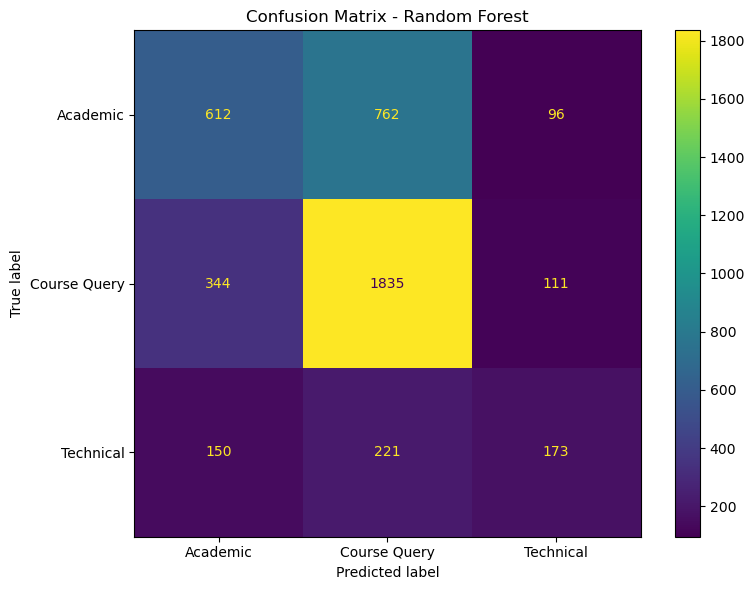

In [43]:
# ============================================================
# 43. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    values_format="d",
    ax=plt.gca()
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# 44. ROC-AUC
# ============================================================

try:

    if hasattr(best_model, "predict_proba"):

        probabilities = best_model.predict_proba(
            X_test_tfidf if best_model_name != "Random Forest"
            and best_model_name != "XGBoost"
            else X_test_dense
        )

        if len(class_names) == 2:

            roc_auc = roc_auc_score(
                y_test,
                probabilities[:, 1]
            )

        else:

            roc_auc = roc_auc_score(
                y_test,
                probabilities,
                multi_class="ovr",
                average="weighted"
            )

        print(
            "\nWeighted ROC-AUC:",
            round(roc_auc, 4)
        )

    elif hasattr(best_model, "decision_function"):

        decision_scores = best_model.decision_function(
            X_test_tfidf
        )

        if len(class_names) == 2:

            roc_auc = roc_auc_score(
                y_test,
                decision_scores
            )

        else:

            roc_auc = roc_auc_score(
                y_test,
                decision_scores,
                multi_class="ovr",
                average="weighted"
            )

        print(
            "\nWeighted ROC-AUC:",
            round(roc_auc, 4)
        )

    else:

        roc_auc = None
        print("\nROC-AUC not available for this model.")

except Exception as e:

    roc_auc = None
    print("\nROC-AUC could not be calculated.")
    print("Reason:", str(e))



Weighted ROC-AUC: 0.736


In [45]:
# ============================================================
# 45. CROSS-VALIDATION OF BEST MODEL
# ============================================================

print("\n" + "=" * 70)
print("CROSS-VALIDATION")
print("=" * 70)

try:

    if best_model_name in [
        "Random Forest",
        "XGBoost"
    ]:

        cv_scores = cross_val_score(
            best_model,
            X_train_dense,
            y_train,
            cv=5,
            scoring="f1_weighted",
            n_jobs=-1
        )

    else:

        cv_scores = cross_val_score(
            best_model,
            X_train_tfidf,
            y_train,
            cv=5,
            scoring="f1_weighted",
            n_jobs=-1
        )

    print("CV F1 scores:")
    print(np.round(cv_scores, 4))

    print(
        "Mean CV F1:",
        round(cv_scores.mean(), 4)
    )

    print(
        "CV Standard Deviation:",
        round(cv_scores.std(), 4)
    )

except Exception as e:

    print("Cross-validation could not be completed.")
    print("Reason:", str(e))




CROSS-VALIDATION
Cross-validation could not be completed.
Reason: Could not pickle the task to send it to the workers.


In [46]:
# ============================================================
# 46. ERROR ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

test_indices = X_test_text.index

error_analysis = pd.DataFrame(
    {
        "Query": X_test_text.values,
        "Actual": label_encoder.inverse_transform(y_test),
        "Predicted": label_encoder.inverse_transform(best_predictions)
    },
    index=test_indices
)

misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print(
    "Total test queries:",
    len(error_analysis)
)

print(
    "Misclassified queries:",
    len(misclassified)
)

print(
    "Error rate:",
    round(
        len(misclassified) / len(error_analysis),
        4
    )
)

print("\nSample misclassified queries:")

display(
    misclassified.head(20)
)



ERROR ANALYSIS
Total test queries: 4304
Misclassified queries: 1684
Error rate: 0.3913

Sample misclassified queries:


,Query,Actual,Predicted
10446,query is suppose completed online class decemb...,Academic,Course Query
19689,mam saw ur recorded lecture sale good act mam ...,Course Query,Academic
4046,hello professor explained treasury share compa...,Academic,Course Query
5780,assignment question select mumbai metro city c...,Course Query,Academic
15192,hi sir monitoring controlling session could se...,Course Query,Technical
9508,sir can plz explain significance business econ...,Academic,Course Query
2038,dear greeting yesterday uber eats question tho...,Academic,Course Query
17796,sir income approach gdp wage interest rent cor...,Course Query,Academic
4671,how decide recruitment strategy approach pleas...,Academic,Course Query
17987,hello management is science well art when see ...,Course Query,Academic


In [47]:
# ============================================================
# 47. SAVE ERROR ANALYSIS
# ============================================================

misclassified_file = os.path.join(
    OUTPUT_FOLDER,
    "misclassified_queries.xlsx"
)

misclassified.to_excel(
    misclassified_file,
    index=False
)

print(
    "\nMisclassified queries saved to:",
    misclassified_file
)



Misclassified queries saved to: student_query_project_output/misclassified_queries.xlsx


In [48]:
# ============================================================
# 48. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("FEATURE ANALYSIS")
print("=" * 70)

if hasattr(best_model, "coef_"):

    coefficients = best_model.coef_

    if coefficients.ndim == 2:

        for class_index, class_name in enumerate(class_names):

            values = coefficients[class_index]

            top_indices = np.argsort(
                np.abs(values)
            )[-15:]

            top_features = feature_names[top_indices]
            top_values = values[top_indices]

            print(
                f"\nTop features for {class_name}:"
            )

            for feature, value in zip(
                top_features[::-1],
                top_values[::-1]
            ):

                print(
                    f"{feature}: {value:.4f}"
                )

elif hasattr(best_model, "feature_importances_"):

    importances = best_model.feature_importances_

    top_indices = np.argsort(
        importances
    )[-20:]

    feature_importance_df = pd.DataFrame(
        {
            "Feature": feature_names[top_indices],
            "Importance": importances[top_indices]
        }
    ).sort_values(
        by="Importance",
        ascending=False
    )

    display(feature_importance_df)

else:

    print(
        "Feature importance is not directly available for this model."
    )



FEATURE ANALYSIS


,Feature,Importance
19,is,0.019498
18,assignment,0.018769
17,session,0.016347
16,question,0.015329
15,sir,0.015003
14,can,0.014445
13,please,0.012981
12,what,0.011300
11,mam,0.010341
10,ia,0.010292


In [49]:
# ============================================================
# 49. SAVE MODEL COMPARISON
# ============================================================

comparison_file = os.path.join(
    OUTPUT_FOLDER,
    "model_comparison.xlsx"
)

final_results_df.to_excel(
    comparison_file,
    index=False
)

print(
    "\nModel comparison saved to:",
    comparison_file
)



Model comparison saved to: student_query_project_output/model_comparison.xlsx


In [50]:
# ============================================================
# 50. SAVE TF-IDF VECTORIZER
# ============================================================

tfidf_file = os.path.join(
    OUTPUT_FOLDER,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    tfidf_vectorizer,
    tfidf_file
)


['student_query_project_output/tfidf_vectorizer.pkl']

In [51]:
# ============================================================
# 51. SAVE LABEL ENCODER
# ============================================================

encoder_file = os.path.join(
    OUTPUT_FOLDER,
    "label_encoder.pkl"
)

joblib.dump(
    label_encoder,
    encoder_file
)


['student_query_project_output/label_encoder.pkl']

In [52]:
# ============================================================
# 52. SAVE BEST MODEL
# ============================================================

model_file = os.path.join(
    OUTPUT_FOLDER,
    "best_model.pkl"
)

joblib.dump(
    best_model,
    model_file
)

print("\nSaved model files:")
print(model_file)
print(tfidf_file)
print(encoder_file)



Saved model files:
student_query_project_output/best_model.pkl
student_query_project_output/tfidf_vectorizer.pkl
student_query_project_output/label_encoder.pkl


In [53]:
# ============================================================
# 53. TEST SAVED MODEL
# ============================================================

print("\n" + "=" * 70)
print("TESTING SAVED MODEL")
print("=" * 70)

loaded_model = joblib.load(
    model_file
)

loaded_vectorizer = joblib.load(
    tfidf_file
)

loaded_encoder = joblib.load(
    encoder_file
)

test_query = (
    "How can I register for my classes?"
)

test_clean = clean_text(
    test_query
)

test_vector = loaded_vectorizer.transform(
    [test_clean]
)

saved_prediction = loaded_model.predict(
    test_vector
)

saved_label = loaded_encoder.inverse_transform(
    saved_prediction
)[0]

print("Test Query:")
print(test_query)

print("\nPredicted Category:")
print(saved_label)



TESTING SAVED MODEL
Test Query:
How can I register for my classes?

Predicted Category:
Academic


In [54]:
# ============================================================
# 54. TEST MULTIPLE SAMPLE QUERIES
# ============================================================

sample_queries = [
    "How do I register for a course?",
    "What are the requirements for my degree?",
    "My computer is not connecting to the WiFi.",
    "How do I reset my password?",
    "When is my assignment due?",
    "I cannot log into my student account.",
    "What classes should I take next semester?",
    "The website is not loading on my laptop."
]

sample_clean = [
    clean_text(q)
    for q in sample_queries
]

sample_vectors = loaded_vectorizer.transform(
    sample_clean
)

sample_predictions = loaded_model.predict(
    sample_vectors
)

sample_labels = loaded_encoder.inverse_transform(
    sample_predictions
)

sample_results = pd.DataFrame(
    {
        "Query": sample_queries,
        "Predicted Category": sample_labels
    }
)

print("\nSample predictions:")

display(sample_results)


Sample predictions:


,Query,Predicted Category
0,How do I register for a course?,Technical
1,What are the requirements for my degree?,Course Query
2,My computer is not connecting to the WiFi.,Course Query
3,How do I reset my password?,Course Query
4,When is my assignment due?,Course Query
5,I cannot log into my student account.,Technical
6,What classes should I take next semester?,Course Query
7,The website is not loading on my laptop.,Course Query


In [55]:
# ============================================================
# 55. FINAL EVALUATION REPORT
# ============================================================

evaluation_report = pd.DataFrame(
    {
        "Metric": [
            "Best Model",
            "Accuracy",
            "Weighted Precision",
            "Weighted Recall",
            "Weighted F1",
            "Number of Classes",
            "Training Samples",
            "Testing Samples"
        ],
        "Value": [
            best_model_name,
            round(final_accuracy, 4),
            round(final_precision, 4),
            round(final_recall, 4),
            round(final_f1, 4),
            len(class_names),
            len(X_train_text),
            len(X_test_text)
        ]
    }
)

if roc_auc is not None:

    evaluation_report = pd.concat(
        [
            evaluation_report,
            pd.DataFrame(
                {
                    "Metric": ["Weighted ROC-AUC"],
                    "Value": [round(roc_auc, 4)]
                }
            )
        ],
        ignore_index=True
    )

evaluation_file = os.path.join(
    OUTPUT_FOLDER,
    "final_evaluation_report.xlsx"
)

evaluation_report.to_excel(
    evaluation_file,
    index=False
)

print("\nFinal evaluation report:")
display(evaluation_report)


Final evaluation report:


,Metric,Value
0,Best Model,Random Forest
1,Accuracy,0.6087
2,Weighted Precision,0.593
3,Weighted Recall,0.6087
4,Weighted F1,0.5919
5,Number of Classes,3
6,Training Samples,17215
7,Testing Samples,4304
8,Weighted ROC-AUC,0.736


In [56]:
# ============================================================
# 56. CREATE FLASK API
# ============================================================

app_code = r'''
from flask import Flask, request, jsonify
import joblib
import re
import os

app = Flask(__name__)

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

model = joblib.load(
    os.path.join(BASE_DIR, "best_model.pkl")
)

vectorizer = joblib.load(
    os.path.join(BASE_DIR, "tfidf_vectorizer.pkl")
)

label_encoder = joblib.load(
    os.path.join(BASE_DIR, "label_encoder.pkl")
)


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    text = re.sub(
        r"&[a-zA-Z0-9#]+;",
        " ",
        text
    )

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


@app.route("/", methods=["GET"])
def home():

    return jsonify(
        {
            "message": "Student Query Classification API",
            "status": "running"
        }
    )


@app.route("/predict", methods=["POST"])
def predict():

    data = request.get_json()

    if data is None:
        return jsonify(
            {
                "error": "Request must contain JSON."
            }
        ), 400

    if "query" not in data:
        return jsonify(
            {
                "error": "JSON must contain a 'query' field."
            }
        ), 400

    query = str(data["query"]).strip()

    if query == "":
        return jsonify(
            {
                "error": "Query cannot be empty."
            }
        ), 400

    cleaned = clean_text(query)

    vector = vectorizer.transform(
        [cleaned]
    )

    prediction = model.predict(
        vector
    )

    label = label_encoder.inverse_transform(
        prediction
    )[0]

    response = {
        "query": query,
        "predicted_category": label
    }

    if hasattr(model, "predict_proba"):

        try:

            probabilities = model.predict_proba(
                vector
            )

            confidence = float(
                max(probabilities[0])
            )

            response["confidence"] = round(
                confidence,
                4
            )

        except Exception:
            pass

    return jsonify(response)


if __name__ == "__main__":

    app.run(
        host="127.0.0.1",
        port=5000,
        debug=False
    )
'''

app_file = os.path.join(
    OUTPUT_FOLDER,
    "app.py"
)

with open(
    app_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(app_code)

print("\nFlask API created:")
print(app_file)


Flask API created:
student_query_project_output/app.py


In [57]:
# ============================================================
# 57. CREATE REQUIREMENTS.TXT
# ============================================================

requirements_text = """numpy
pandas
matplotlib
scikit-learn
nltk
wordcloud
joblib
openpyxl
flask
xgboost
"""

requirements_file = os.path.join(
    OUTPUT_FOLDER,
    "requirements.txt"
)

with open(
    requirements_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(requirements_text)

print("requirements.txt created.")


requirements.txt created.


In [58]:
# ============================================================
# 58. CREATE README
# ============================================================

readme_text = f"""
# Student Query Classification

## Project

Classification of student queries using Natural Language Processing
and Machine Learning.

## Dataset

Student Queries Data.xlsx

Number of original records:
{len(df)}

Number of cleaned records:
{len(data)}

## Classification Categories

{", ".join(class_names)}

## Feature Extraction

TF-IDF with:

- Unigrams
- Bigrams
- Maximum 500 features
- Sublinear TF scaling

## Models

- Logistic Regression
- Tuned Logistic Regression
- Linear SVM
- Tuned Linear SVM
- Random Forest
- XGBoost when available

## Best Model

{best_model_name}

## Final Performance

Accuracy: {final_accuracy:.4f}

Weighted Precision: {final_precision:.4f}

Weighted Recall: {final_recall:.4f}

Weighted F1: {final_f1:.4f}

## Saved Files

- best_model.pkl
- tfidf_vectorizer.pkl
- label_encoder.pkl
- app.py
- requirements.txt
- clean_student_queries.xlsx
- model_comparison.xlsx
- misclassified_queries.xlsx
- final_evaluation_report.xlsx

## Flask API

Run:

python app.py

The API will run at:

http://127.0.0.1:5000

## Prediction Endpoint

POST:

/predict

Example JSON:

{{
    "query": "How do I register for a course?"
}}
"""

readme_file = os.path.join(
    OUTPUT_FOLDER,
    "README.md"
)

with open(
    readme_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(readme_text)

print("README.md created.")



README.md created.


In [60]:
# ============================================================
# 59. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("PROJECT COMPLETE")
print("=" * 70)

print("\nDataset:")
print("  Original rows:", len(df))
print("  Clean rows:", len(data))

print("\nClasses:")
for label in class_names:
    print(" ", label)

print("\nBest Model:")
print(" ", best_model_name)

print("\nPerformance:")
print("  Accuracy :", round(final_accuracy, 4))
print("  Precision:", round(final_precision, 4))
print("  Recall   :", round(final_recall, 4))
print("  F1 Score :", round(final_f1, 4))

print("\nOutput folder:")
print(" ", os.path.abspath(OUTPUT_FOLDER))

print("\nFiles created:")

for filename in sorted(
    os.listdir(OUTPUT_FOLDER)
):

    print("  -", filename)





PROJECT COMPLETE

Dataset:
  Original rows: 22094
  Clean rows: 21519

Classes:
  Academic
  Course Query
  Technical

Best Model:
  Random Forest

Performance:
  Accuracy : 0.6087
  Precision: 0.593
  Recall   : 0.6087
  F1 Score : 0.5919

Output folder:
  /home/c4aa6a31-8778-4e79-96de-ab90cdd4435a/Final Project/student_query_project_output

Files created:
  - README.md
  - app.py
  - best_model.pkl
  - clean_student_queries.xlsx
  - final_evaluation_report.xlsx
  - label_encoder.pkl
  - misclassified_queries.xlsx
  - model_comparison.xlsx
  - requirements.txt
  - tfidf_vectorizer.pkl
